# JPEG AI as a Threat to Deepfake Detection
Lorenzo Pizzi 2187091

## Setup

Installa le dipendenze, clona JPEG AI, compila le estensioni C++ e applica le patch necessarie.
**Va rieseguito ogni sessione Colab** (il runtime `/content/` si azzera ad ogni riavvio).

In [1]:
# ── Architettura ambiente ─────────────────────────────────────────────────
# Il codec JPEG AI richiede numpy 1.x; transformers/torch/detector vogliono
# numpy 2.x. Non possono coesistere in un solo kernel. Soluzione:
#   • kernel principale → numpy 2.x NATIVO di Colab (detector, valutazione)
#   • codec JPEG AI     → venv isolato /content/jpegai_venv con numpy 1.x
# Il codec viene invocato come subprocess col python del venv (JPEG_AI_PYTHON).
# Così il kernel principale non viene mai toccato e gli import non si rompono.

import subprocess, sys, os

# ── 1. Dipendenze di sistema ──────────────────────────────────────────────
!apt-get update -qq
!apt-get install -yq doxygen graphviz git-lfs
!git lfs install

# ── 2. Clona il repository JPEG AI (con i modelli via Git LFS) ───────────
!rm -rf /content/jpeg_ai
!git clone https://gitlab.com/wg1/jpeg-ai/jpeg-ai-reference-software.git /content/jpeg_ai
!git -C /content/jpeg_ai lfs fetch
!git -C /content/jpeg_ai lfs checkout

# ── 3. venv isolato per il codec JPEG AI (numpy 1.x) ─────────────────────
# Si usa `virtualenv` (su Colab `python -m venv` fallisce: manca ensurepip).
# --system-site-packages: il venv eredita torch/torchvision da Colab (sono
# tolleranti alla versione di numpy → niente download da 2 GB). Solo i
# pacchetti ABI-critici (numpy, scipy) vengono sovrascritti dentro al venv.
# I pacchetti si installano col pip del KERNEL PRINCIPALE puntato al venv
# tramite `pip --python <venv>`: il venv creato da virtualenv non ha un pip
# proprio, ma pip moderno sa installare in un ambiente target esterno.
# NB: `--python` è un'opzione GLOBALE → va prima del sottocomando `install`.
!pip install -q virtualenv
JPEG_AI_PYTHON = '/content/jpegai_venv/bin/python'
if not os.path.exists(JPEG_AI_PYTHON):
    subprocess.check_call([sys.executable, '-m', 'virtualenv',
                           '--system-site-packages', '/content/jpegai_venv'])

# Installazione pacchetto-per-pacchetto: numpy/scipy/pybind11 sono CRITICI;
# gli altri sono best-effort — un fallimento isolato (es. build C++ di
# compressai) non blocca il setup. compressai/gputil/nvidia-ml NON servono
# al codec (entropy coding è nelle estensioni C++; il profiler è stubbato
# in cell-3) ma si tentano comunque per completezza.
_venv_pkgs = ['numpy==1.26.4', 'scipy==1.13.1', 'setuptools', 'wheel',
              'pybind11', 'einops', 'addict', 'commentjson',
              'compressai', 'gputil', 'nvidia-ml-py3']
_critical  = {'numpy==1.26.4', 'scipy==1.13.1', 'pybind11'}
_skipped   = []
for _pkg in _venv_pkgs:
    _r = subprocess.run([sys.executable, '-m', 'pip', '--python', JPEG_AI_PYTHON,
                         'install', '-q', _pkg],
                        capture_output=True, text=True)
    if _r.returncode != 0:
        if _pkg in _critical:
            print(f'ERRORE — pacchetto critico {_pkg} non installato:')
            print(_r.stdout[-800:])
            print(_r.stderr[-1500:])
            raise RuntimeError(f'Installazione venv fallita su {_pkg}.')
        _skipped.append(_pkg)
        print(f'Nota: {_pkg} saltato (non critico).')
if _skipped:
    print(f'Pacchetti opzionali saltati: {_skipped}')
print('venv codec JPEG AI pronto.')

# ── 4. Pacchetti detector nel kernel principale (numpy 2.x nativo) ───────
# Nessun downgrade di numpy: lo stack di Colab resta internamente coerente.
# transformers==4.44.2: ultima versione prima del bug @strict su ViTConfig (>=4.47)
!pip install -q "Pillow>=10.4" "transformers==4.44.2" timm safetensors accelerate

# ── 5. Compila le estensioni C++ con il python del venv ──────────────────
os.chdir('/content/jpeg_ai')

setup_code = '''
from setuptools import setup
from pybind11.setup_helpers import Pybind11Extension, build_ext
ext_modules = [
    Pybind11Extension("ans",
        ["src/codec/entropy_coding/cpp_exts/mans/ans.cpp",
         "src/codec/entropy_coding/cpp_exts/mans/compressor.cpp",
         "src/codec/entropy_coding/cpp_exts/mans/decompressor.cpp"],
        extra_compile_args=["-O3", "-fopenmp", "-std=c++14", "-fPIC"],
        extra_link_args=["-fopenmp"]),
    Pybind11Extension("ec_direct",
        ["src/codec/entropy_coding/cpp_exts/direct/py_ec_lib_direct.cpp",
         "src/codec/entropy_coding/cpp_exts/direct/ec_lib_direct.cpp"],
        extra_compile_args=["-O3", "-fopenmp", "-std=c++14", "-fPIC"],
        extra_link_args=["-fopenmp"]),
]
setup(name="jpeg_ai_ext", ext_modules=ext_modules, cmdclass={"build_ext": build_ext})
'''
with open('setup_ext.py', 'w') as f:
    f.write(setup_code)

subprocess.check_call([JPEG_AI_PYTHON, 'setup_ext.py', '-q', 'build_ext', '--inplace'])
!mv ans*.so       src/codec/entropy_coding/lib_wrappers/mans/ 2>/dev/null || true
!mv ec_direct*.so src/codec/entropy_coding/lib_wrappers/direct/ 2>/dev/null || true
print('Setup completato.')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libclang-cpp14 libclang1-14 libllvm14 libxapian30
Suggested packages:
  doxygen-latex doxygen-doc doxygen-gui xapian-tools
The following NEW packages will be installed:
  doxygen git-lfs libclang-cpp14 libclang1-14 libllvm14 libxapian30
0 upgraded, 6 newly installed, 0 to remove and 60 not upgraded.
Need to get 51.7 MB of archives.
After this operation, 229 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libllvm14 amd64 1:14.0.0-1ubuntu1.1 [24.0 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libclang-cpp14 amd64 1:14.0.0-1ubu

In [2]:
# ── Patch 1: pynvml ───────────────────────────────────────────────────────
from pathlib import Path
import shutil

gpu_file = Path('/content/jpeg_ai/src/codec/coding_tools/profiler/gpu_memory_usage.py')
text = gpu_file.read_text()
if 'try:' not in text:
    text = text.replace(
        'from pynvml.smi import nvidia_smi',
        'try:\n    from pynvml.smi import nvidia_smi\n'
        'except ImportError:\n'
        '    class nvidia_smi:\n'
        '        @classmethod\n'
        '        def getInstance(cls):\n'
        '            class _D:\n'
        "                def DeviceQuery(self, *a): return {'gpu': [{'fb_memory_usage': {'total': 1, 'used': 0}}]}\n"
        '            return _D()'
    )
    gpu_file.write_text(text)

# ── Patch 2: ptflops — stub package ───────────────────────────────────────
ptflops_dir = Path('/content/jpeg_ai/ptflops')
ptflops_dir.mkdir(exist_ok=True)
shutil.rmtree(ptflops_dir / '__pycache__', ignore_errors=True)

(ptflops_dir / 'flops_counter.py').write_text(
    "CUSTOM_MODULES_MAPPING = {}\n"
    "def flops_to_string(x, **kw): return '0 GMac'\n"
    "def get_model_complexity_info(*a, **kw): return '0 GMac', '0 M'\n"
    "def ptflops_get_model_bounds(*a, **kw): return None\n"
    "conv_flops_counter_hook = None\n"
)
(ptflops_dir / '__init__.py').write_text(
    "from . import flops_counter\n"
    "def get_model_complexity_info(*a, **kw): return '0 GMac', '0 M'\n"
)

# ── Patch 3: binarizers.py — numpy scalar fix ─────────────────────────────
# bypass_coder.decode() restituisce un array numpy 1-d invece di uno scalare
# nelle versioni recenti → int() fallisce. Fix: usa .item() se disponibile.
binarizers_file = Path('/content/jpeg_ai/src/codec/entropy_coding/binarizers.py')
text = binarizers_file.read_text()
old_line = 'value = int(bypass_coder.decode(1, max_symbol_value=max_v))'
if old_line in text:
    new_line = ('_dv = bypass_coder.decode(1, max_symbol_value=max_v); '
                'value = int(_dv.item() if hasattr(_dv, "item") else _dv)')
    binarizers_file.write_text(text.replace(old_line, new_line))
    print('Patch binarizers.py: OK')
else:
    print('Patch binarizers.py: già applicata o riga non trovata.')

print('Tutte le patch applicate.')


Patch binarizers.py: OK
Tutte le patch applicate.


## Imports

In [3]:
import os
import sys
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from google.colab import drive

import torch
from transformers import pipeline as hf_pipeline

## Globals

In [ ]:
drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────────────────
DEVICE = 0 if torch.cuda.is_available() else -1
print(f'Dispositivo: {"GPU (cuda:0)" if DEVICE == 0 else "CPU"}')

# ── Cartelle (tutte su Drive per persistenza tra sessioni) ────────────────
DRIVE_ROOT   = Path('/content/drive/MyDrive/CV_Project')
DATA_DIR     = DRIVE_ROOT / 'data'
DATASET_DIR  = DATA_DIR / 'raw' / 'openfake_dataset'
MANIFEST_DIR = DATA_DIR / 'manifests'
PNG_DIR      = DATA_DIR / 'png_cache'
COMP_DIR     = DATA_DIR / 'compressed'
RESULTS_DIR  = DRIVE_ROOT / 'results' / 'phase1'

for _d in [DATA_DIR, MANIFEST_DIR, PNG_DIR, COMP_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── JPEG AI ───────────────────────────────────────────────────────────────
JPEG_AI_DIR    = Path('/content/jpeg_ai')
JPEG_AI_PYTHON = '/content/jpegai_venv/bin/python'   # python del venv numpy 1.x
JPEG_AI_CFG    = ['cfg/tools_on.json', 'cfg/profiles/base.json']
JPEG_AI_ENV    = {**os.environ, 'TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD': '1'}

# ── Esperimento ───────────────────────────────────────────────────────────
TARGET_BPP  = [0.12, 0.25, 0.50, 1.00]
N_PER_CLASS = 100

# ── Dataset e detector ────────────────────────────────────────────────────
KAGGLE_DATASET = 'sanketghadge1/openfake-data-20k-img'
IMAGE_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
DETECTOR_MODEL  = 'dima806/deepfake_vs_real_image_detection'
DETECTOR_MODEL2 = 'Wvolf/ViT_Deepfake_Detection'

print('Globals configurati.')


Mounted at /content/drive
Dispositivo: GPU (cuda:0)
Globals configurati.


## Data

**Fase 1 — Pipeline dati (4 passi):**
1. Scarica OpenFake 20k da Kaggle → skip se già su Drive
2. Costruisce un manifest CSV con path, label e split di ogni immagine
3. Campiona `N_PER_CLASS` immagini per classe dal test split
4. Comprime ogni immagine con JPEG AI ai livelli BPP definiti sopra

In [11]:
# ── Passo 1: scarica il dataset (skip se già su Drive) ────────────────────
if DATASET_DIR.exists() and any(DATASET_DIR.iterdir()):
    print(f'Dataset già presente: {DATASET_DIR}')
else:
    print('Scaricamento da Kaggle...')
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    result = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', KAGGLE_DATASET,
        '-p', str(DATASET_DIR.parent),
        '--unzip', '--force',
    ], capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('Download fallito. Controlla ~/.kaggle/kaggle.json.')
    print('Download completato.')

Dataset già presente: /content/drive/MyDrive/CV_Project/data/raw/openfake_dataset


In [12]:
# ── Passo 2: costruisce (o carica) il manifest ────────────────────────────
# Il manifest è un CSV con una riga per immagine:
#   image_id | path | label | label_id | split
#
# label_id: 0 = real, 1 = fake
# Se il manifest esiste già su Drive, lo carica senza riscansionare.

MANIFEST_PATH = MANIFEST_DIR / 'dataset.csv'

if MANIFEST_PATH.exists():
    df = pd.read_csv(str(MANIFEST_PATH))
    print(f'Manifest caricato: {len(df)} immagini')
else:
    print('Costruzione manifest (solo listing, nessuna apertura immagini)...')
    rows = []
    for split in ['train', 'test']:
        for label in ['real', 'fake']:
            folder = DATASET_DIR / split / label
            if not folder.exists():
                continue
            files = [p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS]
            for img_path in tqdm(files, desc=f'{split}/{label}'):
                rows.append({
                    'image_id': img_path.stem,
                    'path':     str(img_path),
                    'label':    label,
                    'label_id': 0 if label == 'real' else 1,
                    'split':    split,
                })

    df = pd.DataFrame(rows)
    df.to_csv(str(MANIFEST_PATH), index=False)
    print(f'Manifest salvato: {len(df)} immagini')

print('\nRiepilogo dataset:')
print(df.groupby(['split', 'label']).size().to_string())


Manifest caricato: 19944 immagini

Riepilogo dataset:
split  label
test   fake     1987
       real     2002
train  fake     7948
       real     8007


In [13]:
# ── Passo 3: costruisce test_sample includendo immagini già processate ────
# Se compression.csv esiste, include sempre le immagini già compresse
# e aggiunge nuove immagini fino a N_PER_CLASS per classe.

test_df   = df[df['split'] == 'test'].copy()
real_pool = test_df[test_df['label'] == 'real']
fake_pool = test_df[test_df['label'] == 'fake']

_comp_path = MANIFEST_DIR / 'compression.csv'
if _comp_path.exists():
    try:
        _existing_ids = set(pd.read_csv(str(_comp_path))['image_id'].astype(str).unique())
    except Exception:
        _existing_ids = set()
else:
    _existing_ids = set()

def _build_sample(pool, existing_ids, n_per_class, seed):
    already    = pool[pool['image_id'].astype(str).isin(existing_ids)]
    remaining  = pool[~pool['image_id'].astype(str).isin(existing_ids)]
    n_new      = max(0, n_per_class - len(already))
    new        = remaining.sample(min(len(remaining), n_new), random_state=seed)
    return pd.concat([already, new])

test_sample = pd.concat([
    _build_sample(real_pool, _existing_ids, N_PER_CLASS, SEED),
    _build_sample(fake_pool, _existing_ids, N_PER_CLASS, SEED),
]).reset_index(drop=True)

n_real = (test_sample['label'] == 'real').sum()
n_fake = (test_sample['label'] == 'fake').sum()
n_old  = test_sample['image_id'].astype(str).isin(_existing_ids).sum()
n_new  = len(test_sample) - n_old
print(f'Subset per compressione + valutazione:')
print(f'  real: {n_real} | fake: {n_fake} | totale: {len(test_sample)}')
print(f'  già processate: {n_old} | nuove da comprimere: {n_new}')
print(f'  chiamate encoder previste: {n_new} × {len(TARGET_BPP)} = {n_new * len(TARGET_BPP)}')


Subset per compressione + valutazione:
  real: 100 | fake: 100 | totale: 200
  già processate: 200 | nuove da comprimere: 0
  chiamate encoder previste: 0 × 4 = 0


In [14]:
# ── RECOVERY: decodifica i .bits esistenti e ricostruisce compression.csv ─
# Esegui questa cella se hai i .bits in compressed/ ma non i .png ricostruiti
# e/o compression.csv è mancante/vuoto. Poi esegui normalmente la compressione.

COMP_MANIFEST = MANIFEST_DIR / 'compression.csv'

def _csv_is_valid(path):
    try:
        return len(pd.read_csv(str(path))) > 0
    except Exception:
        return False

if COMP_MANIFEST.exists() and _csv_is_valid(COMP_MANIFEST):
    print('compression.csv già presente e valido — nessuna recovery necessaria.')
else:
    if COMP_MANIFEST.exists():
        COMP_MANIFEST.unlink()

    label_map = dict(zip(
        test_sample['image_id'].astype(str),
        zip(test_sample['label'], test_sample['label_id'])
    ))

    recovered  = []
    decoded    = 0
    dec_errors = []

    for bpp in TARGET_BPP:
        tag       = f'bpp_{bpp:.2f}'
        bit_dir   = COMP_DIR / tag / 'bitstream'
        recon_dir = COMP_DIR / tag / 'recon'
        if not bit_dir.exists():
            continue
        recon_dir.mkdir(parents=True, exist_ok=True)

        for bit_path in tqdm(list(bit_dir.glob('*.bits')), desc=f'Decode {tag}'):
            img_id   = bit_path.stem
            rec_path = recon_dir / f'{img_id}.png'

            # Decodifica se il .png ricostruito non esiste ancora
            if not rec_path.exists():
                dec = subprocess.run([
                    JPEG_AI_PYTHON, '-m', 'src.reco.coders.decoder',
                    str(bit_path), str(rec_path),
                ], cwd=JPEG_AI_DIR, env=JPEG_AI_ENV, capture_output=True, text=True)
                if dec.returncode != 0:
                    dec_errors.append(f'{img_id} BPP={bpp}: {dec.stderr[-200:]}')
                    continue
                decoded += 1

            if not rec_path.exists():
                continue

            # Calcola BPP misurato — usa png_cache se disponibile per dimensioni esatte
            png_path = PNG_DIR / f'{img_id}.png'
            src_img  = png_path if png_path.exists() else rec_path
            with Image.open(src_img) as im:
                w, h = im.size
            measured_bpp = round((bit_path.stat().st_size * 8) / (w * h), 4)

            label, label_id = label_map.get(img_id, ('unknown', -1))
            recovered.append({
                'image_id':     img_id,
                'label':        label,
                'label_id':     int(label_id),
                'target_bpp':   bpp,
                'measured_bpp': measured_bpp,
                'recon_path':   str(rec_path),
            })

    if dec_errors:
        print(f'Errori di decodifica ({len(dec_errors)}):')
        for e in dec_errors[:3]:
            print(f'  {e}')

    if recovered:
        comp_df = pd.DataFrame(recovered)
        comp_df.to_csv(str(COMP_MANIFEST), index=False)
        print(f'Recovery completata: {decoded} nuove decodifiche, {len(comp_df)} record totali.')
        print(comp_df.groupby('target_bpp').size().to_string())
        print('\nOra esegui la cella di compressione: salterà tutto il già fatto.')
    else:
        print('Nessun .bits trovato — la compressione partirà da zero.')


compression.csv già presente e valido — nessuna recovery necessaria.


In [15]:
# ── Passo 4: compressione JPEG AI ─────────────────────────────────────────
COMP_MANIFEST = MANIFEST_DIR / 'compression.csv'

if COMP_MANIFEST.exists():
    try:
        comp_df = pd.read_csv(str(COMP_MANIFEST))
        done = {
            (str(r['image_id']), round(float(r['target_bpp']), 4))
            for _, r in comp_df.iterrows()
            if Path(r['recon_path']).exists()
        }
        print(f'Ripresa: {len(done)} coppie immagine×BPP già completate.')
    except pd.errors.EmptyDataError:
        print('compression.csv vuoto — si riparte da zero.')
        COMP_MANIFEST.unlink()
        comp_df = pd.DataFrame()
        done    = set()
else:
    comp_df = pd.DataFrame()
    done    = set()

new_rows = []
errors   = []
t_start  = time.time()

# JPEG_AI_ALIGN: multiplo di padding per le dimensioni dell'immagine.
# JPEG AI a BPP alto usa più stadi di trasformazione; se una feature map
# interna scende sotto 3 pixel, l'unfold 3×3 fallisce. 256 garantisce un
# margine sufficiente per tutti i livelli BPP testati.
JPEG_AI_ALIGN = 256

for _, row in tqdm(test_sample.iterrows(), total=len(test_sample), desc='Immagini'):
    img_id = str(row['image_id'])
    src    = Path(row['path'])

    with Image.open(src) as _src_im:
        orig_w, orig_h = _src_im.size

    aligned_w = max(JPEG_AI_ALIGN, ((orig_w + JPEG_AI_ALIGN - 1) // JPEG_AI_ALIGN) * JPEG_AI_ALIGN)
    aligned_h = max(JPEG_AI_ALIGN, ((orig_h + JPEG_AI_ALIGN - 1) // JPEG_AI_ALIGN) * JPEG_AI_ALIGN)
    needs_pad = (aligned_w != orig_w or aligned_h != orig_h)

    png_path = PNG_DIR / f'{img_id}.png'
    _cached_size = Image.open(png_path).size if png_path.exists() else None
    if not png_path.exists() or (needs_pad and _cached_size != (aligned_w, aligned_h)):
        _img = Image.open(src).convert('RGB')
        if needs_pad:
            _padded = Image.new('RGB', (aligned_w, aligned_h), (128, 128, 128))
            _padded.paste(_img, (0, 0))
            _padded.save(png_path)
        else:
            _img.save(png_path)

    for bpp in TARGET_BPP:
        key = (img_id, round(bpp, 4))
        if key in done:
            continue

        tag      = f'bpp_{bpp:.2f}'
        bit_path = COMP_DIR / tag / 'bitstream' / f'{img_id}.bits'
        rec_path = COMP_DIR / tag / 'recon'     / f'{img_id}.png'
        bit_path.parent.mkdir(parents=True, exist_ok=True)
        rec_path.parent.mkdir(parents=True, exist_ok=True)

        # Il codec gira col python del venv isolato (numpy 1.x)
        enc = subprocess.run([
            JPEG_AI_PYTHON, '-m', 'src.reco.coders.encoder',
            str(png_path), str(bit_path),
            '--set_target_bpp', str(int(round(bpp * 100))),
            '--cfg', *JPEG_AI_CFG,
        ], cwd=JPEG_AI_DIR, env=JPEG_AI_ENV, capture_output=True, text=True)

        if enc.returncode != 0:
            errors.append(f'{img_id} BPP={bpp}: {enc.stderr[-300:]}')
            continue

        dec = subprocess.run([
            JPEG_AI_PYTHON, '-m', 'src.reco.coders.decoder',
            str(bit_path), str(rec_path),
        ], cwd=JPEG_AI_DIR, env=JPEG_AI_ENV, capture_output=True, text=True)

        if dec.returncode != 0:
            errors.append(f'{img_id} BPP={bpp} decode: {dec.stderr[-300:]}')
            continue

        # BPP calcolato sui pixel originali (non sul canvas paddato)
        measured_bpp = round((bit_path.stat().st_size * 8) / (orig_w * orig_h), 4)

        new_rows.append({
            'image_id':     img_id,
            'label':        row['label'],
            'label_id':     int(row['label_id']),
            'target_bpp':   bpp,
            'measured_bpp': measured_bpp,
            'recon_path':   str(rec_path),
        })
        done.add(key)

        if len(new_rows) % 10 == 0:
            comp_df = pd.concat([comp_df, pd.DataFrame(new_rows)], ignore_index=True)
            comp_df.to_csv(str(COMP_MANIFEST), index=False)
            new_rows = []

if new_rows:
    comp_df = pd.concat([comp_df, pd.DataFrame(new_rows)], ignore_index=True)
    comp_df.to_csv(str(COMP_MANIFEST), index=False)

elapsed = round(time.time() - t_start)
print(f'\nCompressione completata in {elapsed//60} min {elapsed%60} s')
print(f'Record totali: {len(comp_df)} / {len(test_sample)*len(TARGET_BPP)} attesi')
if errors:
    print(f'Errori ({len(errors)}): mostra i primi 3:')
    for e in errors[:3]:
        print(f'  {e}')


Ripresa: 800 coppie immagine×BPP già completate.


Immagini:   0%|          | 0/200 [00:00<?, ?it/s]


Compressione completata in 3 min 9 s
Record totali: 800 / 800 attesi


In [16]:
# ── Verifica risultati compressione ───────────────────────────────────────
comp_df = pd.read_csv(str(COMP_MANIFEST))
print(f'comp_df: {len(comp_df)} righe')
total_expected = len(test_sample) * len(TARGET_BPP)
missing_files  = [r['recon_path'] for _, r in comp_df.iterrows()
                  if not Path(r['recon_path']).exists()]

print(f'Progresso: {len(comp_df)}/{total_expected} coppie ({100*len(comp_df)//total_expected}%)')
if missing_files:
    print(f'ATTENZIONE: {len(missing_files)} file ricostruiti mancanti — riesegui la cella precedente.')
else:
    print('Tutti i file ricostruiti sono presenti su disco.')

print('\nBPP misurato vs target (media ± std):')
print(comp_df.groupby('target_bpp')['measured_bpp'].agg(['mean', 'std']).round(4).to_string())

comp_df: 800 righe
Progresso: 800/800 coppie (100%)
Tutti i file ricostruiti sono presenti su disco.

BPP misurato vs target (media ± std):
              mean     std
target_bpp                
0.12        0.1218  0.0089
0.25        0.2581  0.0181
0.50        0.5113  0.0372
1.00        1.0137  0.0951


## Network

Carica il detector pre-trained da HuggingFace e definisce la funzione di valutazione.

**Detector scelto**: `dima806/deepfake_vs_real_image_detection`  
ViT-base fine-tuned su dataset di volti reali e generati da AI. Input: immagine RGB → Output: score P(real) e P(fake).

In [19]:
detector = hf_pipeline('image-classification', model=DETECTOR_MODEL, device=DEVICE)

_probe = Image.open(test_sample.iloc[0]['path']).convert('RGB')
_out   = detector(_probe)
print(f'Output del modello: {_out}')
print(f'Nomi delle label: {[r["label"] for r in _out]}')


def fake_prob(img_path: str) -> float:
    result = detector(Image.open(img_path).convert('RGB'))
    scores = {r['label'].upper(): r['score'] for r in result}
    for name in ['FAKE', 'DEEPFAKE', 'AI', 'ARTIFICIAL', 'GENERATED']:
        if name in scores:
            return float(scores[name])
    for name in ['REAL', 'AUTHENTIC', 'GENUINE']:
        if name in scores:
            return 1.0 - float(scores[name])
    return float(max(scores.values()))


print('Detector 1 pronto.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

Output del modello: [{'label': 'Real', 'score': 0.6435511112213135}, {'label': 'Fake', 'score': 0.32882794737815857}]
Nomi delle label: ['Real', 'Fake']
Detector 1 pronto.


In [17]:
# ── Detector 2: CLIP-Det (Cozzolino et al., CVPRW 2024) ──────────────────
# Riferimento [35] di Cannas et al. — uno dei detector usati esattamente
# nel paper di riferimento. Feature CLIP + classificatore lineare;
# generalizzazione cross-generator molto superiore ai detector HuggingFace.

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch'], check=True)

CLIPDET_DIR = Path('/content/ClipBased-SyntheticImageDetection')
if not CLIPDET_DIR.exists():
    subprocess.run(['git', 'clone', '--depth=1',
        'https://github.com/grip-unina/ClipBased-SyntheticImageDetection.git',
        str(CLIPDET_DIR)], check=True)
    subprocess.run(['git', 'lfs', 'pull'], cwd=str(CLIPDET_DIR), check=True)
    print('CLIP-Det: repo clonato e pesi scaricati.')
else:
    print('CLIP-Det: repo già presente.')

# Smoke test — verifica che main.py funzioni e rileva il nome della colonna score
_test_csv = Path('/content/clipdet_smoke.csv')
_test_out = Path('/content/clipdet_smoke_out.csv')
pd.DataFrame({'filename': [test_sample.iloc[0]['path']]}).to_csv(str(_test_csv), index=False)

_r = subprocess.run([
    sys.executable, str(CLIPDET_DIR / 'main.py'),
    '--in_csv', str(_test_csv), '--out_csv', str(_test_out), '--device', 'cuda:0',
], capture_output=True, text=True, cwd=str(CLIPDET_DIR))

if _r.returncode != 0:
    print('ERRORE smoke test:')
    print(_r.stderr[-500:])
else:
    _smoke = pd.read_csv(str(_test_out))
    print(f'Output columns: {list(_smoke.columns)}')
    CLIPDET_SCORE_COL = [c for c in _smoke.columns if c.lower() != 'filename'][0]
    _score_val = float(_smoke.iloc[0][CLIPDET_SCORE_COL])
    print(f'Score column: "{CLIPDET_SCORE_COL}" | valore: {_score_val:.4f} → {"synthetic" if _score_val > 0 else "real"}')
    print('Detector 2 (CLIP-Det) pronto.')


CLIP-Det: repo clonato e pesi scaricati.
Output columns: ['filename', 'clipdet_latent10k_plus', 'Corvi2023', 'fusion']
Score column: "clipdet_latent10k_plus" | valore: 0.6703 → synthetic
Detector 2 (CLIP-Det) pronto.


## Train

*Placeholder — Fase 3: strategie di mitigazione (fine-tuning su dati compressi, domain adaptation, ecc.)*

In [ ]:
# Fase 3 — da implementare

## Evaluation

**Fase 1 — Baseline evaluation:**
1. Valuta il detector sulle immagini **originali** (non compresse) → baseline
2. Valuta sulle immagini **ricostruite da JPEG AI** per ogni livello BPP
3. Produce tabella AUC / Accuracy / F1 e i tre grafici della degradazione

In [20]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve


def evaluate(pairs: list, desc: str = 'Valutazione', threshold: float = 0.5) -> dict:
    scores, labels = [], []
    for img_path, true_label in tqdm(pairs, desc=desc):
        try:
            scores.append(fake_prob(img_path))
            labels.append(int(true_label))
        except Exception as e:
            print(f'  Saltata {Path(img_path).name}: {e}')

    scores = np.array(scores)
    labels = np.array(labels)
    preds  = (scores >= threshold).astype(int)
    return {
        'scores': scores, 'labels': labels,
        'auc': float(roc_auc_score(labels, scores)),
        'acc': float(accuracy_score(labels, preds)),
        'f1':  float(f1_score(labels, preds, zero_division=0)),
        'n':   len(labels),
    }


# ── 1. Immagini originali — calcola soglia ottimale dalla curva ROC ───────
pairs_orig = [(row['path'], row['label_id']) for _, row in test_sample.iterrows()]
print(f'=== Originali ({len(pairs_orig)} immagini) ===')
res_orig = evaluate(pairs_orig, desc='Originali', threshold=0.5)

# Soglia ottimale: massimizza l'indice di Youden (TPR - FPR)
fpr_v, tpr_v, thresholds_v = roc_curve(res_orig['labels'], res_orig['scores'])
youden_idx   = np.argmax(tpr_v - fpr_v)
OPT_THRESHOLD = float(thresholds_v[youden_idx])
print(f'  Soglia ottimale (Youden): {OPT_THRESHOLD:.4f}')

# Ricalcola con soglia ottimale
res_orig = evaluate(pairs_orig, desc='Originali (opt thr)', threshold=OPT_THRESHOLD)
print(f'  AUC={res_orig["auc"]:.4f}  Acc={res_orig["acc"]:.4f}  F1={res_orig["f1"]:.4f}\n')

# ── 2. Immagini compresse — usa la stessa soglia ottimale ─────────────────
res_bpp = {}
for bpp in sorted(TARGET_BPP):
    subset = comp_df[comp_df['target_bpp'].round(4) == round(bpp, 4)].copy()
    pairs  = [(row['recon_path'], row['label_id']) for _, row in subset.iterrows()]
    avg    = subset['measured_bpp'].mean()

    print(f'=== BPP target={bpp}  misurato={avg:.3f}  ({len(pairs)} immagini) ===')
    res_bpp[bpp] = evaluate(pairs, desc=f'BPP={bpp}', threshold=OPT_THRESHOLD)
    r = res_bpp[bpp]
    print(f'  AUC={r["auc"]:.4f}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}\n')


=== Originali (200 immagini) ===


Originali:   0%|          | 0/200 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Soglia ottimale (Youden): 0.0931


Originali (opt thr):   0%|          | 0/200 [00:00<?, ?it/s]

...

  AUC=0.5974  Acc=0.5650  F1=0.5297

=== BPP target=0.5  misurato=0.511  (200 immagini) ===


BPP=0.5:   0%|          | 0/200 [00:00<?, ?it/s]

  AUC=0.5995  Acc=0.5750  F1=0.5503

=== BPP target=1.0  misurato=1.014  (200 immagini) ===


BPP=1.0:   0%|          | 0/200 [00:00<?, ?it/s]

  AUC=0.5971  Acc=0.5700  F1=0.5474



In [ ]:
# ── Valutazione Detector 2: CLIP-Det — 3 score in un unico run ───────────
# main.py produce 3 colonne nello stesso run di inferenza:
#   • clipdet_latent10k_plus → detector CLIP-based (Cozzolino et al., [35])
#   • Corvi2023              → detector per immagini da diffusion model
#   • fusion                 → fusione dei due (di norma il più forte)
# Score = LLR; soglia LLR>0 → fake. L'AUC è la metrica affidabile (indipendente
# dalla soglia); Acc/F1 a soglia 0 non sono calibrate su OpenFake.
def evaluate_clipdet(image_paths: list, true_labels: list, tag: str = 'eval') -> dict:
    """Restituisce {nome_colonna: {auc, acc, f1, scores, labels, n}}."""
    in_csv  = Path(f'/content/clipdet_{tag}.csv')
    out_csv = Path(f'/content/clipdet_{tag}_out.csv')
    pd.DataFrame({'filename': image_paths}).to_csv(str(in_csv), index=False)

    r = subprocess.run([
        sys.executable, str(CLIPDET_DIR / 'main.py'),
        '--in_csv', str(in_csv), '--out_csv', str(out_csv), '--device', 'cuda:0',
    ], capture_output=True, text=True, cwd=str(CLIPDET_DIR))
    if r.returncode != 0:
        raise RuntimeError(f'CLIP-Det errore:\n{r.stderr[-400:]}')

    res    = pd.read_csv(str(out_csv)).set_index('filename').reindex(image_paths).reset_index()
    labels = np.array(true_labels, dtype=int)
    out    = {}
    for col in [c for c in res.columns if c.lower() != 'filename']:
        scores = res[col].values.astype(float)
        preds  = (scores > 0).astype(int)
        out[col] = {
            'scores': scores, 'labels': labels,
            'auc': float(roc_auc_score(labels, scores)),
            'acc': float(accuracy_score(labels, preds)),
            'f1':  float(f1_score(labels, preds, zero_division=0)),
            'n':   len(labels),
        }
    return out

orig_paths  = [row['path']          for _, row in test_sample.iterrows()]
orig_labels = [int(row['label_id']) for _, row in test_sample.iterrows()]

print(f'=== CLIP-Det — Originali ({len(orig_paths)} immagini) ===')
res_orig2 = evaluate_clipdet(orig_paths, orig_labels, tag='orig')
for col, m in res_orig2.items():
    print(f'  {col:24s} AUC={m["auc"]:.4f}  Acc={m["acc"]:.4f}  F1={m["f1"]:.4f}')
print()

res_bpp2 = {}
for bpp in sorted(TARGET_BPP):
    subset = comp_df[comp_df['target_bpp'].round(4) == round(bpp, 4)].copy()
    paths  = list(subset['recon_path'])
    labels = list(subset['label_id'].astype(int))
    print(f'=== CLIP-Det BPP={bpp}  ({len(paths)} immagini) ===')
    res_bpp2[bpp] = evaluate_clipdet(paths, labels, tag=f'bpp_{bpp}')
    for col, m in res_bpp2[bpp].items():
        print(f'  {col:24s} AUC={m["auc"]:.4f}  Acc={m["acc"]:.4f}  F1={m["f1"]:.4f}')
    print()

# ── Tabella comparativa — AUC (metrica affidabile, indipendente da soglia) ─
_cols  = list(res_orig2.keys())   # ordine: clipdet_latent10k_plus, Corvi2023, fusion
_short = {'clipdet_latent10k_plus': 'CLIP', 'Corvi2023': 'Corvi23', 'fusion': 'fusion'}
print('=' * 70)
print('  CONFRONTO DETECTOR — AUC')
print('=' * 70)
_hdr = f'{"BPP":<12} {"D1":>9}'
for c in _cols:
    _hdr += f' {_short.get(c, c[:9]):>9}'
print(_hdr)
print('-' * 70)
_row = f'{"Originale":<12} {res_orig["auc"]:>9.4f}'
for c in _cols:
    _row += f' {res_orig2[c]["auc"]:>9.4f}'
print(_row)
for bpp in sorted(TARGET_BPP):
    _row = f'{bpp:<12} {res_bpp[bpp]["auc"]:>9.4f}'
    for c in _cols:
        _row += f' {res_bpp2[bpp][c]["auc"]:>9.4f}'
    print(_row)
print('=' * 70)


=== CLIP-Det — Originali (200 immagini) ===
  clipdet_latent10k_plus   AUC=0.6043  Acc=0.5400  F1=0.4026
  Corvi2023                AUC=0.9289  Acc=0.8400  F1=0.8095
  fusion                   AUC=0.8904  Acc=0.7800  F1=0.7864

=== CLIP-Det BPP=0.12  (200 immagini) ===
  clipdet_latent10k_plus   AUC=0.4099  Acc=0.4050  F1=0.4936
  Corvi2023                AUC=0.4340  Acc=0.4500  F1=0.5703
  fusion                   AUC=0.4127  Acc=0.4900  F1=0.6531

=== CLIP-Det BPP=0.25  (200 immagini) ===
  clipdet_latent10k_plus   AUC=0.4203  Acc=0.4450  F1=0.4478
  Corvi2023                AUC=0.6676  Acc=0.5850  F1=0.3664
  fusion                   AUC=0.5217  Acc=0.5100  F1=0.5739

=== CLIP-Det BPP=0.5  (200 immagini) ===
  clipdet_latent10k_plus   AUC=0.4509  Acc=0.4350  F1=0.3957
  Corvi2023                AUC=0.8736  Acc=0.5950  F1=0.3306
  fusion                   AUC=0.5777  Acc=0.5150  F1=0.5268

=== CLIP-Det BPP=1.0  (200 immagini) ===
  clipdet_latent10k_plus   AUC=0.4906  Acc=0.4900  F1=

  FASE 1 — AUC per detector e livello di compressione
      BPP     D1  clipdet_latent10k_plus  Corvi2023  fusion
Originale 0.5885                  0.6043     0.9289  0.8904
      1.0 0.5971                  0.4906     0.9225  0.7090
      0.5 0.5995                  0.4509     0.8736  0.5777
     0.25 0.5974                  0.4203     0.6676  0.5217
     0.12 0.5850                  0.4099     0.4340  0.4127


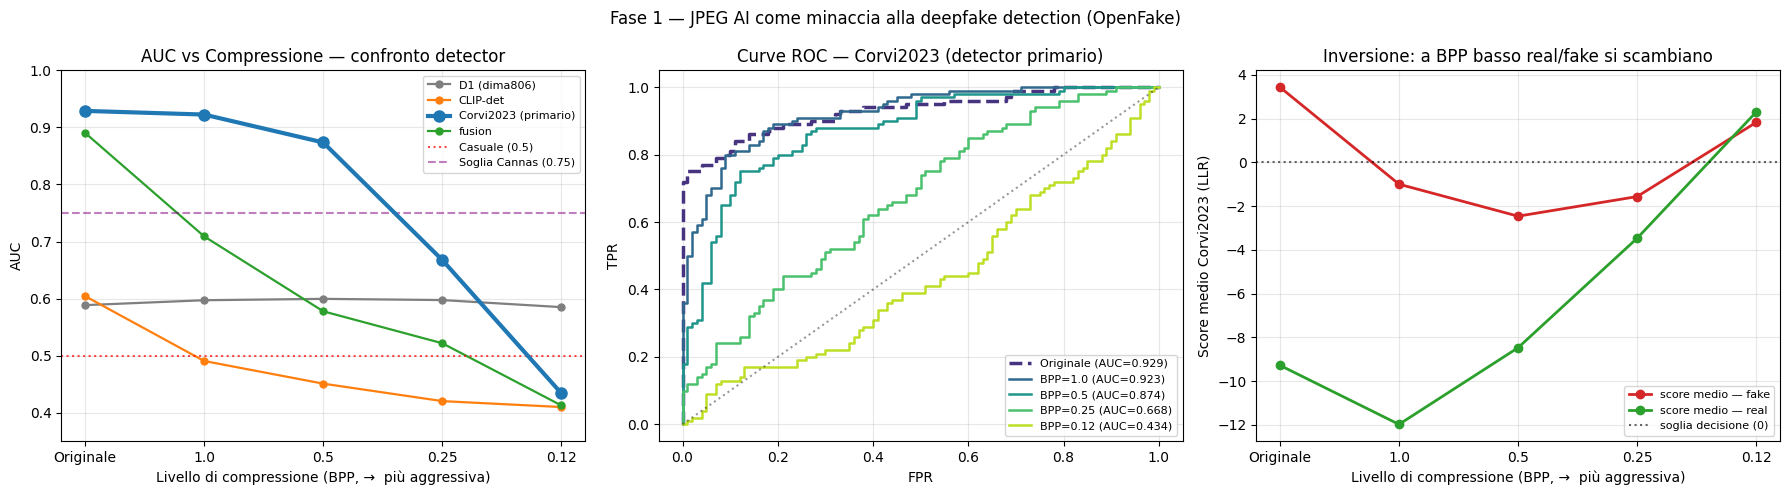

Grafici salvati:   /content/drive/MyDrive/CV_Project/results/phase1/phase1_results.png
Metriche salvate:  /content/drive/MyDrive/CV_Project/results/phase1/phase1_metrics.csv
Dettaglio Corvi2023: /content/drive/MyDrive/CV_Project/results/phase1/phase1_corvi2023.csv


In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Detector di riferimento Fase 1: Corvi2023 ────────────────────────────
# È l'unico con baseline > 0.75 su OpenFake originale (criterio di Cannas):
# l'unico su cui la misura dell'effetto counter-forensic è legittima.
PRIMARY  = 'Corvi2023'
bpp_desc = sorted(TARGET_BPP, reverse=True)          # 1.0 → 0.12 (qualità calante)
x_labels = ['Originale'] + [str(b) for b in bpp_desc]
x_pos    = list(range(len(x_labels)))

# Serie AUC (originale + per BPP) di un detector
def _auc_series(name):
    if name == 'D1':
        return [res_orig['auc']] + [res_bpp[b]['auc'] for b in bpp_desc]
    return [res_orig2[name]['auc']] + [res_bpp2[b][name]['auc'] for b in bpp_desc]

detectors = ['D1', 'clipdet_latent10k_plus', 'Corvi2023', 'fusion']

# ── Tabella riassuntiva: AUC di tutti i detector ─────────────────────────
results_df = pd.DataFrame({'BPP': x_labels})
for d in detectors:
    results_df[d] = _auc_series(d)
print('=' * 72)
print('  FASE 1 — AUC per detector e livello di compressione')
print('=' * 72)
print(results_df.to_string(index=False,
      float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
print('=' * 72)
results_df.to_csv(str(RESULTS_DIR / 'phase1_metrics.csv'), index=False)

# Tabella dettagliata del detector primario (AUC/Acc/F1)
_prim = [{'BPP': 'Originale', **{k: res_orig2[PRIMARY][k] for k in ('auc', 'acc', 'f1')}}]
for b in bpp_desc:
    _prim.append({'BPP': b, **{k: res_bpp2[b][PRIMARY][k] for k in ('auc', 'acc', 'f1')}})
pd.DataFrame(_prim).to_csv(str(RESULTS_DIR / 'phase1_corvi2023.csv'), index=False)

# ── Grafici ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fase 1 — JPEG AI come minaccia alla deepfake detection (OpenFake)',
             fontsize=12)

_style = {
    'D1':                     ('D1 (dima806)',         'tab:gray'),
    'clipdet_latent10k_plus': ('CLIP-det',             'tab:orange'),
    'Corvi2023':              ('Corvi2023 (primario)', 'tab:blue'),
    'fusion':                 ('fusion',               'tab:green'),
}

# Grafico 1: AUC vs compressione — confronto di tutti i detector
ax = axes[0]
for d in detectors:
    name, color = _style[d]
    is_prim = (d == PRIMARY)
    ax.plot(x_pos, _auc_series(d), 'o-', color=color,
            lw=3 if is_prim else 1.6, ms=8 if is_prim else 5,
            zorder=3 if is_prim else 2, label=name)
ax.axhline(0.5,  color='red',    ls=':',  alpha=0.7, label='Casuale (0.5)')
ax.axhline(0.75, color='purple', ls='--', alpha=0.5, label='Soglia Cannas (0.75)')
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels)
ax.set(xlabel='Livello di compressione (BPP, →  più aggressiva)', ylabel='AUC',
       title='AUC vs Compressione — confronto detector', ylim=(0.35, 1.0))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Grafico 2: curve ROC del detector primario per livello BPP
ax = axes[1]
palette = cm.viridis(np.linspace(0.15, 0.9, len(bpp_desc) + 1))
fpr, tpr, _ = roc_curve(res_orig2[PRIMARY]['labels'], res_orig2[PRIMARY]['scores'])
ax.plot(fpr, tpr, '--', color=palette[0], lw=2.5,
        label=f'Originale (AUC={res_orig2[PRIMARY]["auc"]:.3f})')
for i, b in enumerate(bpp_desc):
    m = res_bpp2[b][PRIMARY]
    fpr, tpr, _ = roc_curve(m['labels'], m['scores'])
    ax.plot(fpr, tpr, color=palette[i + 1], lw=1.8,
            label=f'BPP={b} (AUC={m["auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.4)
ax.set(xlabel='FPR', ylabel='TPR',
       title=f'Curve ROC — {PRIMARY} (detector primario)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Grafico 3: score medio per classe — visualizza l'inversione counter-forensic
ax = axes[2]
conds = [res_orig2[PRIMARY]] + [res_bpp2[b][PRIMARY] for b in bpp_desc]
real_means = [m['scores'][m['labels'] == 0].mean() for m in conds]
fake_means = [m['scores'][m['labels'] == 1].mean() for m in conds]
ax.plot(x_pos, fake_means, 'o-', color='tab:red',   lw=2, ms=6, label='score medio — fake')
ax.plot(x_pos, real_means, 'o-', color='tab:green', lw=2, ms=6, label='score medio — real')
ax.axhline(0, color='k', ls=':', alpha=0.6, label='soglia decisione (0)')
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels)
ax.set(xlabel='Livello di compressione (BPP, →  più aggressiva)',
       ylabel=f'Score medio {PRIMARY} (LLR)',
       title='Inversione: a BPP basso real/fake si scambiano')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = RESULTS_DIR / 'phase1_results.png'
plt.savefig(str(plot_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafici salvati:   {plot_path}')
print(f'Metriche salvate:  {RESULTS_DIR / "phase1_metrics.csv"}')
print(f'Dettaglio {PRIMARY}: {RESULTS_DIR / "phase1_corvi2023.csv"}')
